In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
sensor_data_cols = ["Time(s)","I_LOAD", "P_H2", "P_AIR", "T_H2O_IN", "T_H2O_OUT", "T_H2O_MEAN", "R"]

In [3]:
# ¨Polarization test: temperature and pressure
pola_data_T50 = {}
pola_data_T50["P300"]= []
pola_data_T50["P400"]= []
pola_data_T50["P500"]= []
aux_data_T50 = {}
aux_data_T50["P300"]= []
aux_data_T50["P400"]= []
aux_data_T50["P500"]= []
workbook_sheets = pd.read_excel("SYNTH_T50_N1.xlsx", sheet_name=None)
for sheet_name, record in workbook_sheets.items():
    if "REC" in sheet_name:
        Pdes = round(np.mean(record["P_H2"]),-2)
        pola_data_T50[f"P{int(Pdes)}"].append((np.mean(record["VFC"]), np.mean(record["I_LOAD"])))
        aux_data_T50[f"P{int(Pdes)}"].append(record[sensor_data_cols])


In [4]:
pola_data_T60 = {}
pola_data_T60["P300"] = []
pola_data_T60["P400"] = []
pola_data_T60["P500"] = []
aux_data_T60 = {}
aux_data_T60["P300"] = []
aux_data_T60["P400"] = []
aux_data_T60["P500"] = []
workbook_sheets_T60 = pd.read_excel("SYNTH_T60_N1.xlsx", sheet_name=None)
for sheet_name, record in workbook_sheets_T60.items():
    if "REC" in sheet_name:
        Pdes = round(np.mean(record["P_H2"]), -2)
        pola_data_T60[f"P{int(Pdes)}"].append((np.mean(record["VFC"]), np.mean(record["I_LOAD"])))
        aux_data_T60[f"P{int(Pdes)}"].append(record[sensor_data_cols])


pola_data_T70 = {}
pola_data_T70["P300"] = []
pola_data_T70["P400"] = []
pola_data_T70["P500"] = []
aux_data_T70 = {}
aux_data_T70["P300"] = []
aux_data_T70["P400"] = []
aux_data_T70["P500"] = []
workbook_sheets_T70 = pd.read_excel("SYNTH_T70_N1.xlsx", sheet_name=None)
for sheet_name, record in workbook_sheets_T70.items():
    if "REC" in sheet_name:
        Pdes = round(np.mean(record["P_H2"]), -2)
        if Pdes < 380:
            Pdes = 300
        pola_data_T70[f"P{int(Pdes)}"].append((np.mean(record["VFC"]), np.mean(record["I_LOAD"])))
        aux_data_T70[f"P{int(Pdes)}"].append(record[sensor_data_cols])

for pressure in aux_data_T50:
    if aux_data_T50[pressure]:
        aux_data_T50[pressure] = (
            pd.concat(aux_data_T50[pressure], ignore_index=True)
            .sort_values(sensor_data_cols[0])
            .reset_index(drop=True)
        )
    else:
        aux_data_T50[pressure] = pd.DataFrame(columns=sensor_data_cols)

for pressure in aux_data_T60:
    if aux_data_T60[pressure]:
        aux_data_T60[pressure] = (
            pd.concat(aux_data_T60[pressure], ignore_index=True)
            .sort_values(sensor_data_cols[0])
            .reset_index(drop=True)
        )
    else:
        aux_data_T60[pressure] = pd.DataFrame(columns=sensor_data_cols)

for pressure in aux_data_T70:
    if aux_data_T70[pressure]:
        aux_data_T70[pressure] = (
            pd.concat(aux_data_T70[pressure], ignore_index=True)
            .sort_values(sensor_data_cols[0])
            .reset_index(drop=True)
        )
    else:
        aux_data_T70[pressure] = pd.DataFrame(columns=sensor_data_cols)

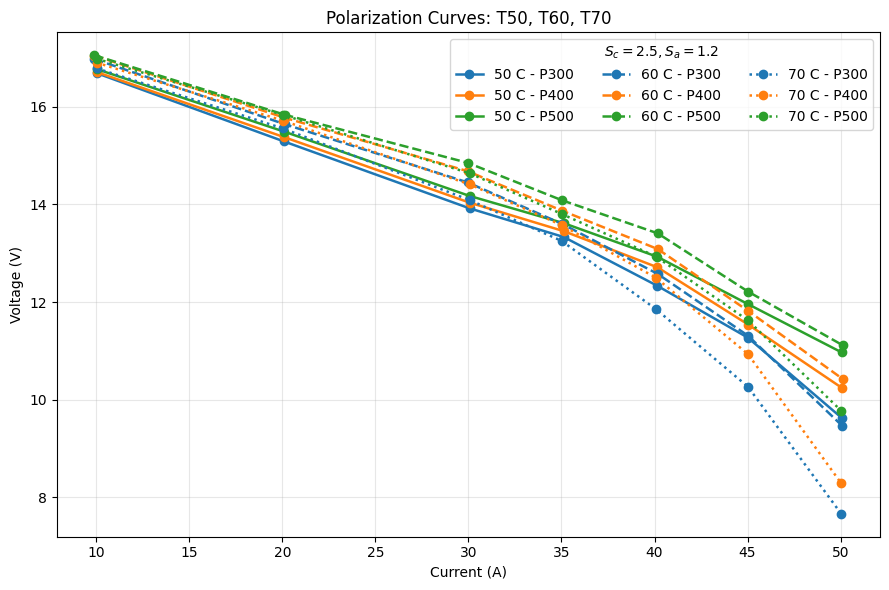

In [5]:
all_pola_data = {"T50": pola_data_T50, "T60": pola_data_T60, "T70": pola_data_T70}
pressure_colors = {"P300": "tab:blue", "P400": "tab:orange", "P500": "tab:green"}
temp_linestyles = {"T50": "-", "T60": "--", "T70": ":"}
temp_labels = {"T50": "50 C", "T60": "60 C", "T70": "70 C"}

plt.figure(figsize=(9, 6))

for temp_label, pola_data in all_pola_data.items():
    for pressure, points in sorted(pola_data.items()):
        if not points:
            continue

        df = pd.DataFrame(points, columns=["VFC", "I_LOAD"]).sort_values("I_LOAD")
        plt.plot(
            df["I_LOAD"],
            df["VFC"],
            marker="o",
            linewidth=1.8,
            color=pressure_colors.get(pressure, None),
            linestyle=temp_linestyles.get(temp_label, "-"),
            label=f"{temp_labels.get(temp_label, temp_label)} - {pressure}",
        )

plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Polarization Curves: T50, T60, T70")
plt.grid(True, alpha=0.3)
plt.legend(title=r"$S_c = 2.5, S_a = 1.2$", ncol=3)
plt.tight_layout()
plt.show()

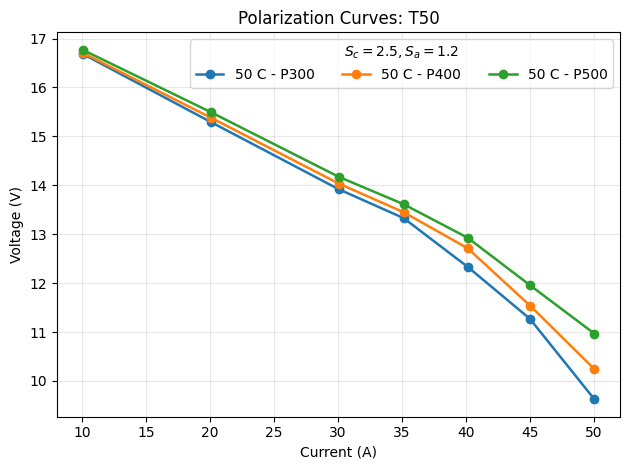

In [9]:
for pressure, points in sorted(pola_data_T50.items()):
    if not points:
        continue

    df = pd.DataFrame(points, columns=["VFC", "I_LOAD"]).sort_values("I_LOAD")
    plt.plot(
    df["I_LOAD"],
    df["VFC"],
    marker="o",
    linewidth=1.8,
    color=pressure_colors.get(pressure, None),
    linestyle=temp_linestyles.get("T50", "-"),
    label=f"{temp_labels.get("T50", "T50")} - {pressure}",
        )

plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Polarization Curves: T50")
plt.grid(True, alpha=0.3)
plt.legend(title=r"$S_c = 2.5, S_a = 1.2$", ncol=3)
plt.tight_layout()
plt.show()

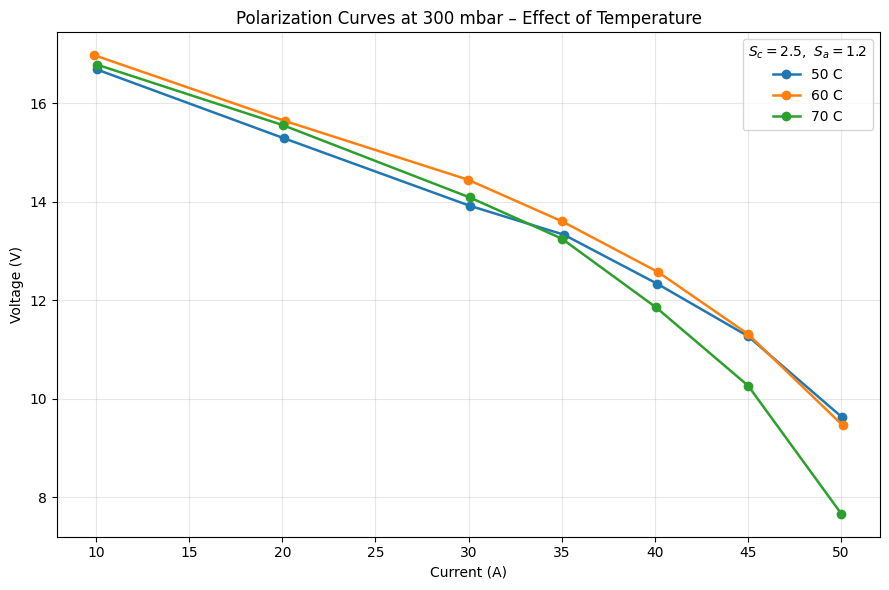

In [7]:

# Polarization curves at P300 for different temperatures
temp_colors = {"T50": "tab:blue", "T60": "tab:orange", "T70": "tab:green"}

plt.figure(figsize=(9, 6))

for temp_label, pola_data in all_pola_data.items():
    points = pola_data.get("P300", [])
    if not points:
        continue
    df = pd.DataFrame(points, columns=["VFC", "I_LOAD"]).sort_values("I_LOAD")
    plt.plot(
        df["I_LOAD"],
        df["VFC"],
        marker="o",
        linewidth=1.8,
        color=temp_colors[temp_label],
        label=temp_labels[temp_label],
    )

plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Polarization Curves at 300 mbar – Effect of Temperature")
plt.grid(True, alpha=0.3)
plt.legend(title=r"$S_c = 2.5,\ S_a = 1.2$")
plt.tight_layout()
plt.show()


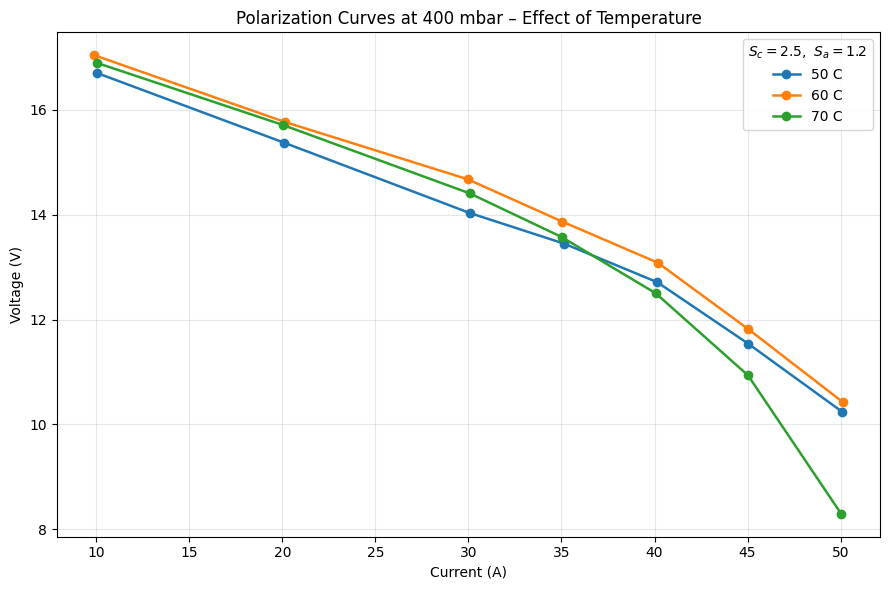

In [8]:

# Polarization curves at P400 for different temperatures
plt.figure(figsize=(9, 6))

for temp_label, pola_data in all_pola_data.items():
    points = pola_data.get("P400", [])
    if not points:
        continue
    df = pd.DataFrame(points, columns=["VFC", "I_LOAD"]).sort_values("I_LOAD")
    plt.plot(
        df["I_LOAD"],
        df["VFC"],
        marker="o",
        linewidth=1.8,
        color=temp_colors[temp_label],
        label=temp_labels[temp_label],
    )

plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Polarization Curves at 400 mbar – Effect of Temperature")
plt.grid(True, alpha=0.3)
plt.legend(title=r"$S_c = 2.5,\ S_a = 1.2$")
plt.tight_layout()
plt.show()


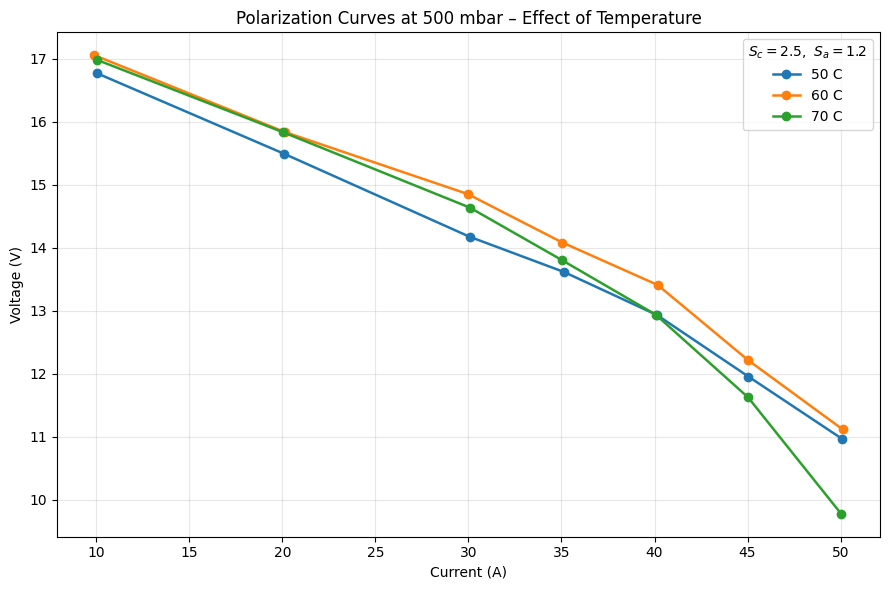

In [9]:

# Polarization curves at P500 for different temperatures
plt.figure(figsize=(9, 6))

for temp_label, pola_data in all_pola_data.items():
    points = pola_data.get("P500", [])
    if not points:
        continue
    df = pd.DataFrame(points, columns=["VFC", "I_LOAD"]).sort_values("I_LOAD")
    plt.plot(
        df["I_LOAD"],
        df["VFC"],
        marker="o",
        linewidth=1.8,
        color=temp_colors[temp_label],
        label=temp_labels[temp_label],
    )

plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Polarization Curves at 500 mbar – Effect of Temperature")
plt.grid(True, alpha=0.3)
plt.legend(title=r"$S_c = 2.5,\ S_a = 1.2$")
plt.tight_layout()
plt.show()


- It seems that high temperature will delay the water flooding current value. The positive effect of temperature is more obvious. 
- High temperature results in high water content in the inlet air. Inversely, we have higher saturation pressure, which will cause less liquid water accumulation? so finally, it should be a drying fault at high current range and reinforced by high temperatures. This is to be verified. 

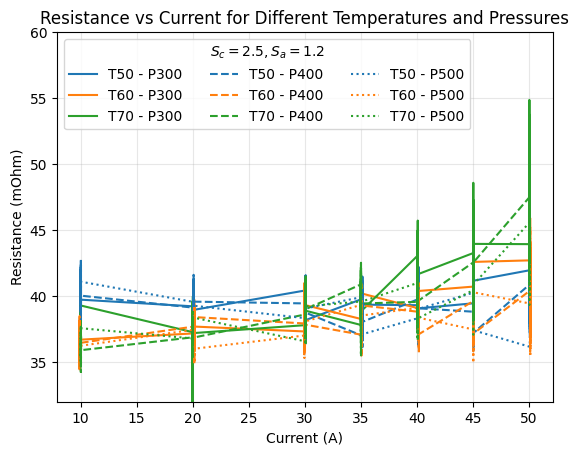

In [6]:
# HFR 
plt.plot(aux_data_T50["P300"]["I_LOAD"], aux_data_T50["P300"]["R"], label="T50 - P300", color="tab:blue")
plt.plot(aux_data_T60["P300"]["I_LOAD"], aux_data_T60["P300"]["R"], label="T60 - P300", color="tab:orange")
plt.plot(aux_data_T70["P300"]["I_LOAD"], aux_data_T70["P300"]["R"], label="T70 - P300", color="tab:green")
plt.plot(aux_data_T50["P400"]["I_LOAD"], aux_data_T50["P400"]["R"], label="T50 - P400", color="tab:blue", linestyle="--")
plt.plot(aux_data_T60["P400"]["I_LOAD"], aux_data_T60["P400"]["R"], label="T60 - P400", color="tab:orange", linestyle="--")
plt.plot(aux_data_T70["P400"]["I_LOAD"], aux_data_T70["P400"]["R"], label="T70 - P400", color="tab:green", linestyle="--")
plt.plot(aux_data_T50["P500"]["I_LOAD"], aux_data_T50["P500"]["R"], label="T50 - P500", color="tab:blue", linestyle=":")
plt.plot(aux_data_T60["P500"]["I_LOAD"], aux_data_T60["P500"]["R"], label="T60 - P500", color="tab:orange", linestyle=":")
plt.plot(aux_data_T70["P500"]["I_LOAD"], aux_data_T70["P500"]["R"], label="T70 - P500", color="tab:green", linestyle=":")
plt.xlabel("Current (A)")
plt.ylabel("Resistance (mOhm)")
plt.title("Resistance vs Current for Different Temperatures and Pressures")
plt.grid(True, alpha=0.3)
plt.ylim(32, 60)
plt.legend(title=r"$S_c = 2.5, S_a = 1.2$", ncol=3)

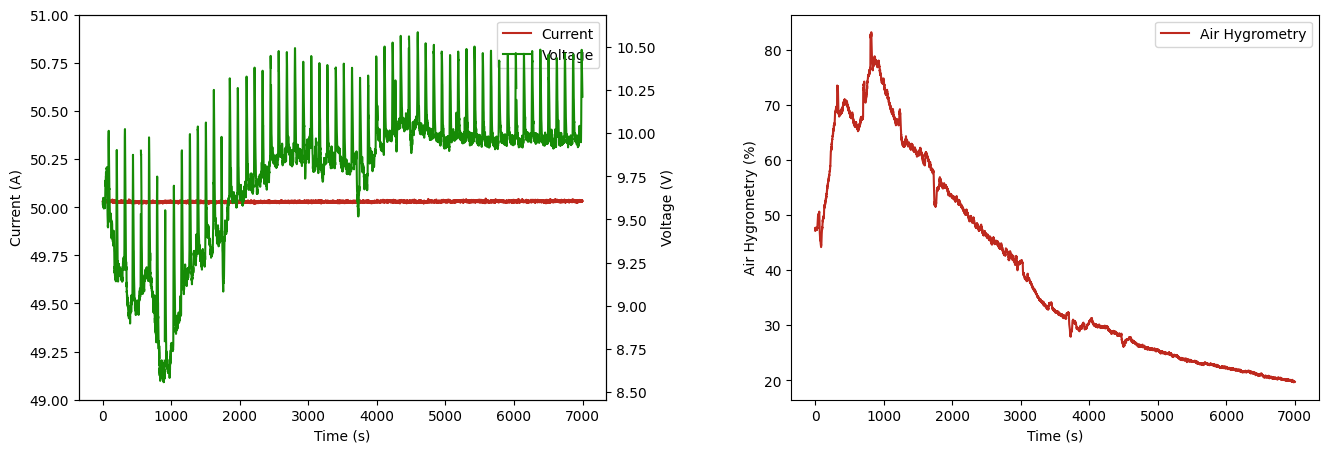

In [ ]:
# High current region : too much water blocked the supply of oxygen, higher temperature help removing water, but also significantly increase the generated water
pola_data_HRC = pd.read_excel("REC_03032026_154026.xlsx")
fig, axes = plt.subplots(figsize=(16, 5), ncols=2, nrows=1)
fig.subplots_adjust(wspace=0.35)
line_current, = axes[0].plot(pola_data_HRC["I_LOAD"][:7000], color="#be291e", label="Current")
axes[0].set_ylabel("Current (A)")
axes[0].set_ylim(49, 51)
axes[0].set_xlabel("Time (s)")
ax2 = axes[0].twinx()
ax2.set_ylabel("Voltage (V)")
line_voltage, = ax2.plot(pola_data_HRC["VFC"][:7000], color="#168b06", label="Voltage")
axes[0].legend(handles=[line_current, line_voltage], loc="upper right")
axes[1].plot(pola_data_HRC["HR_AIR_FC"][:7000], color="#be291e", label="Air Hygrometry")
axes[1].set_ylabel("Air Hygrometry (%)")
axes[1].set_xlabel("Time (s)")
axes[1].legend(loc="upper right")

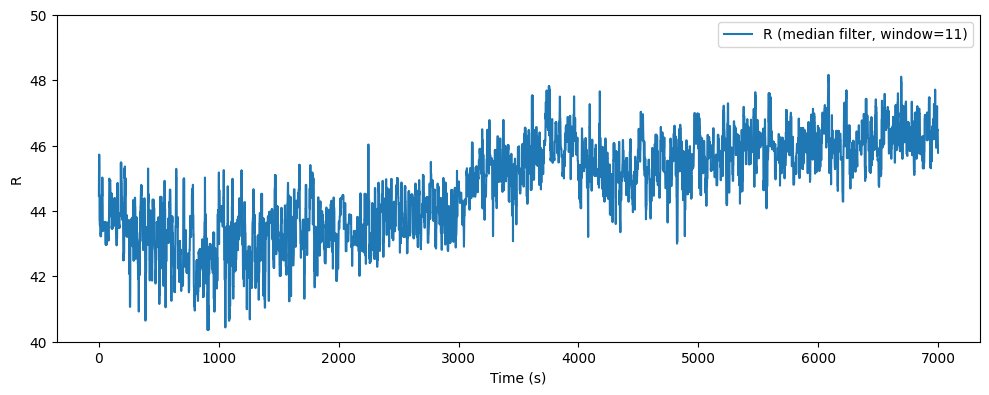

In [8]:
median_window = 11
r_filtered = pola_data_HRC["R"][:7000].rolling(window=median_window, center=True, min_periods=1).median()

plt.figure(figsize=(10, 4))
plt.plot(r_filtered, color="#1f77b4", label=f"R (median filter, window={median_window})")
plt.xlabel("Time (s)")
plt.ylabel("R")
plt.legend()
plt.tight_layout()
plt.ylim(40,50)
plt.show()

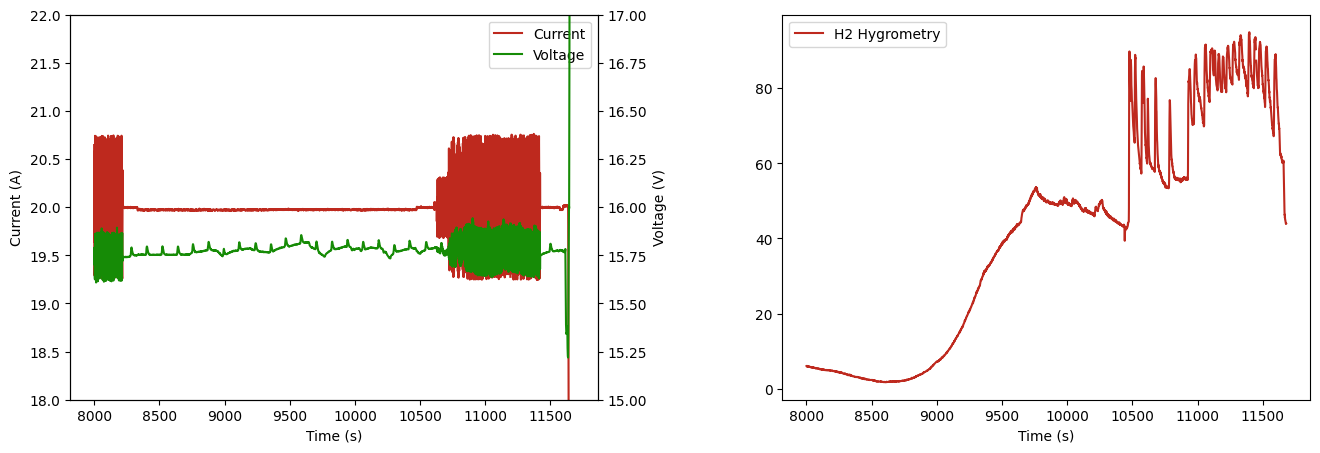

In [ ]:
# There is is several EIS test during this test that can be observed from the voltage measurement
i_start = 8000
i_end = -1
# High cathode stoichiometry and gradual humidification at the anode
pola_data_Sc = pd.read_excel("REC_24022026_142125.xlsx")
fig, axes = plt.subplots(figsize=(16, 5), ncols=2, nrows=1)
fig.subplots_adjust(wspace=0.35)
line_current, = axes[0].plot(pola_data_Sc["I_LOAD"][i_start:i_end], color="#be291e", label="Current")
axes[0].set_ylabel("Current (A)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylim(18, 22)
ax2 = axes[0].twinx()
ax2.set_ylabel("Voltage (V)")
line_voltage, = ax2.plot(pola_data_Sc["VFC"][i_start:i_end], color="#168b06", label="Voltage")
ax2.set_ylim(15, 17)
axes[0].legend(handles=[line_current, line_voltage])
axes[1].plot(pola_data_Sc["HR_H2_FC"][i_start:i_end], color="#be291e", label="H2 Hygrometry")
axes[1].set_xlabel("Time (s)")
axes[1].legend(loc="upper left")

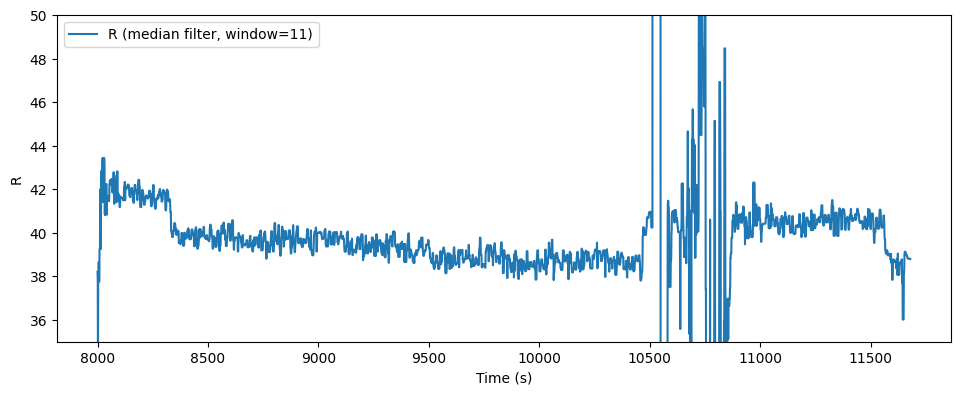

In [10]:
median_window = 11
r_filtered = pola_data_Sc["R"][i_start:i_end].rolling(window=median_window, center=True, min_periods=1).median()

plt.figure(figsize=(10, 4))
plt.plot(r_filtered, color="#1f77b4", label=f"R (median filter, window={median_window})")
plt.xlabel("Time (s)")
plt.ylabel("R")
plt.legend()
plt.tight_layout()
plt.ylim(35,50)
plt.show()